# Rental Price Prediction – Kuala Lumpur & Selangor

## Problem Statement
Rent in KL and Selangor depends on many things: location, size, rooms, furnishing and property type.
It is hard for tenants and owners to know if a listed rent is fair.

**Who is the user?** People looking for a place to rent in KL or Selangor (tenants). Before they sign a contract, they want to know: *"Is this rent fair, or am I overpaying?"*

- **Objective:** build a machine learning model that predicts the fair monthly rent of a property from its features.
- **Why it matters:** tenants can avoid overpaying, negotiate with a real number, and find areas that fit their budget.
- **Expected outcome:** a trained regression model and a React web app (**SewaCheck**) where a tenant can:
  1. check if a listing's asking rent is fair, and get a suggested offer
  2. find which areas fit their budget for the unit they want
  3. see market insights (which factors make rent higher)

## Dataset
- **Source:** Kaggle – Rent Pricing Kuala Lumpur, Malaysia (scraped from mudah.my)
  https://www.kaggle.com/datasets/ariewijaya/rent-pricing-kuala-lumpur-malaysia
- **Size:** 19,991 listings, 14 columns
- **Target variable:** `monthly_rent`
- **Features used:** location, property type, rooms, parking, bathroom, size, furnished, region

## Step 1: Import the libraries

In [1]:
# --- Core data handling ---
import pandas as pd
import numpy as np
import json                      # save the model for the React website

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine learning (scikit-learn) ---
from sklearn.model_selection import train_test_split          # split data into train/test
from sklearn.preprocessing import StandardScaler              # scale numbers
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

# Make charts look clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Show all columns when we print a DataFrame
pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load the dataset

In [2]:

# read_csv() loads the CSV file into a pandas DataFrame 
df = pd.read_csv("mudah-apartment-kl-selangor.csv")

# .shape gives (number_of_rows, number_of_columns)
print("Dataset shape (rows, columns):", df.shape)

# .head() shows the first 5 rows so we can see what the data looks like
df.head()

Dataset shape (rows, columns): (19991, 14)


,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swi...","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, ...","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur
2,100323128,Pangsapuri Teratak Muhibbah 2,NaN,RM 1 000 per month,Kuala Lumpur - Taman Desa,Apartment,3,NaN,2.0,650 sq.ft.,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur
3,100191767,Sentul Point Suite Apartment,2020.0,RM 1 700 per month,Kuala Lumpur - Sentul,Apartment,2,1.0,2.0,743 sq.ft.,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Cou...","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur
4,97022692,Arte Mont Kiara,NaN,RM 1 299 per month,Kuala Lumpur - Mont Kiara,Service Residence,1,1.0,1.0,494 sq.ft.,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...",Air-Cond,Kuala Lumpur


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ads_id                 19991 non-null  int64  
 1   prop_name              19043 non-null  object 
 2   completion_year        10806 non-null  float64
 3   monthly_rent           19989 non-null  object 
 4   location               19991 non-null  object 
 5   property_type          19991 non-null  object 
 6   rooms                  19985 non-null  object 
 7   parking                14289 non-null  float64
 8   bathroom               19985 non-null  float64
 9   size                   19991 non-null  object 
 10  furnished              19986 non-null  object 
 11  facilities             17782 non-null  object 
 12  additional_facilities  14043 non-null  object 
 13  region                 19991 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 2.1+

## Step 3: Data cleaning

### 3.1 Find the missing values

In [4]:
print("Missing values per column:")
df.isnull().sum().sort_values(ascending=False)

Missing values per column:


completion_year          9185
additional_facilities    5948
parking                  5702
facilities               2209
prop_name                 948
rooms                       6
bathroom                    6
furnished                   5
monthly_rent                2
ads_id                      0
location                    0
property_type               0
size                        0
region                      0
dtype: int64

`completion_year` is missing in almost half the rows, and `parking` is missing in many rows.

### 3.2 Remove duplicates
Some listings were posted more than once (same details, different `ads_id`). We remove them so the model doesn't learn the same property twice.

In [5]:
print("Rows before:", len(df))

# Check duplicates using every column except ads_id
df = df.drop_duplicates(subset=df.columns.drop("ads_id"))

print("Rows after:", len(df))

Rows before: 19991
Rows after: 18450


### 3.3 Fix the data types
`monthly_rent` is text like `"RM 4 200 per month"` and `size` is text like `"1842 sq.ft."`. We remove the extra words and change them to numbers.
`errors="coerce"` turns anything that is not a number (like `"More than 10"`) into empty (NaN).

In [6]:
# "RM 4 200 per month"  ->  4200
df["monthly_rent"] = (df["monthly_rent"]
                      .str.replace("RM", "")
                      .str.replace("per month", "")
                      .str.replace(" ", ""))
df["monthly_rent"] = pd.to_numeric(df["monthly_rent"], errors="coerce")

# "1842 sq.ft."  ->  1842
df["size"] = df["size"].str.replace("sq.ft.", "").str.strip()
df["size"] = pd.to_numeric(df["size"], errors="coerce")

# "3.0" -> 3.0,  "More than 10" -> NaN
df["rooms"] = pd.to_numeric(df["rooms"], errors="coerce")

df[["monthly_rent", "size", "rooms"]].head()

,monthly_rent,size,rooms
0,4200.0,1842,5.0
1,2300.0,1170,3.0
2,1000.0,650,3.0
3,1700.0,743,2.0
4,1299.0,494,1.0


### 3.4 Clean the location
`"Kuala Lumpur - Taman Desa"` becomes `"Taman Desa"`. The region is already in its own column.

In [7]:
df["location"] = df["location"].str.split(" - ").str[1]
df["location"].value_counts().head(10)

location
Cheras            1958
Kajang             900
Shah Alam          900
Setapak            889
Cyberjaya          809
Puchong            758
Sentul             691
Seri Kembangan     682
Kepong             632
Ampang             591
Name: count, dtype: int64

### 3.5 Drop columns we don't use
- `ads_id`, `prop_name` – IDs and building names
- `completion_year` – almost half is missing
- `facilities`, `additional_facilities` – long text lists

In [8]:
df = df.drop(columns=["ads_id", "prop_name", "completion_year",
                      "facilities", "additional_facilities"])
df.head()

,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,region
0,4200.0,Taman Desa,Condominium,5.0,2.0,6.0,1842,Fully Furnished,Kuala Lumpur
1,2300.0,Cheras,Condominium,3.0,1.0,2.0,1170,Partially Furnished,Kuala Lumpur
2,1000.0,Taman Desa,Apartment,3.0,NaN,2.0,650,Fully Furnished,Kuala Lumpur
3,1700.0,Sentul,Apartment,2.0,1.0,2.0,743,Partially Furnished,Kuala Lumpur
4,1299.0,Mont Kiara,Service Residence,1.0,1.0,1.0,494,Not Furnished,Kuala Lumpur


### 3.6 Handle the remaining missing values
- `parking`: fill with the median (1)
- other columns: only a few rows are empty, so we remove them

In [9]:
df["parking"] = df["parking"].fillna(df["parking"].median())
df = df.dropna()

print("Missing values left:", df.isnull().sum().sum())
print("Rows now:", len(df))

Missing values left: 0
Rows now: 18440


### 3.7 Group rare property types
Types with very few listings (e.g. "Bungalow House") become "Others", because the model can't learn from so few examples.

In [10]:
# The property types we want to keep
main_types = ["Condominium", "Service Residence", "Apartment", "Flat", "Studio", "Duplex"]

# Any type NOT in the list becomes "Others"
df.loc[~df["property_type"].isin(main_types), "property_type"] = "Others"

df["property_type"].value_counts()

property_type
Condominium          7710
Service Residence    4910
Apartment            4905
Flat                  550
Studio                176
Others                115
Duplex                 74
Name: count, dtype: int64

### 3.8 Remove outliers
Some listings have impossible values (e.g. rent of RM 2,400,000 or size of 1 sq.ft.). We keep only sensible values:
rent between RM 300 and RM 10,000, and size between 200 and 5,000 sq.ft.

In [11]:
print("Before:", len(df))

# Keep only sensible rents and sizes
df = df[df["monthly_rent"].between(300, 10000)]
df = df[df["size"].between(200, 5000)]

print("After:", len(df))

Before: 18440
After: 18258


In [12]:
df[["monthly_rent", "size"]].describe()


,monthly_rent,size
count,18258.000000,18258.000000
mean,1609.739073,918.645963
std,824.357980,304.255176
min,300.000000,200.000000
25%,1100.000000,750.000000
50%,1450.000000,893.000000
75%,1850.000000,1044.000000
max,10000.000000,5000.000000


### 3.9 Save the cleaned dataset

In [13]:
df.to_csv("cleaned_rent_data.csv", index=False)
print("Saved cleaned_rent_data.csv")

Saved cleaned_rent_data.csv


## Step 4: Exploratory Data Analysis (EDA)

### 4.1 Descriptive statistics

In [14]:
df.describe()


,monthly_rent,rooms,parking,bathroom,size
count,18258.000000,18258.000000,18258.000000,18258.00000,18258.000000
mean,1609.739073,2.687479,1.295651,1.89369,918.645963
std,824.357980,0.799530,0.507385,0.54830,304.255176
min,300.000000,1.000000,1.000000,1.00000,200.000000
25%,1100.000000,2.000000,1.000000,2.00000,750.000000
50%,1450.000000,3.000000,1.000000,2.00000,893.000000
75%,1850.000000,3.000000,2.000000,2.00000,1044.000000
max,10000.000000,10.000000,10.000000,8.00000,5000.000000


**Insight:** the median rent is RM 1,450 and the average is about RM 1,610. A typical unit is about 900 sq.ft. with 3 rooms and 2 bathrooms.

### 4.2 Distribution of rent

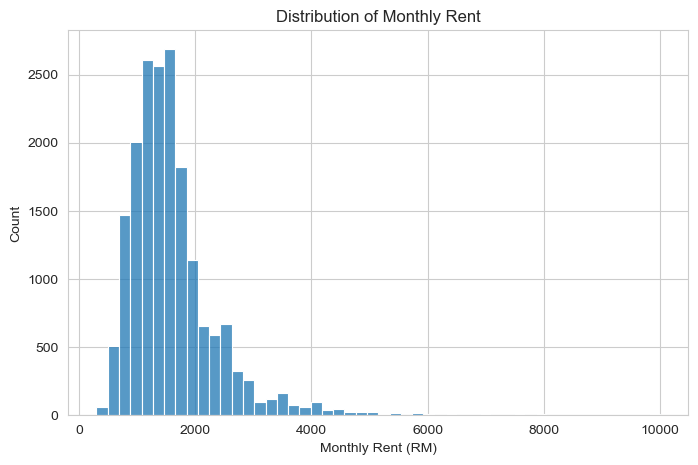

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["monthly_rent"], bins=50)
plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent (RM)")
plt.show()

**Insight:** most rents are between RM 1,000 and RM 2,000. A few luxury units are much more expensive (long tail on the right).

### 4.3 Rent by property type

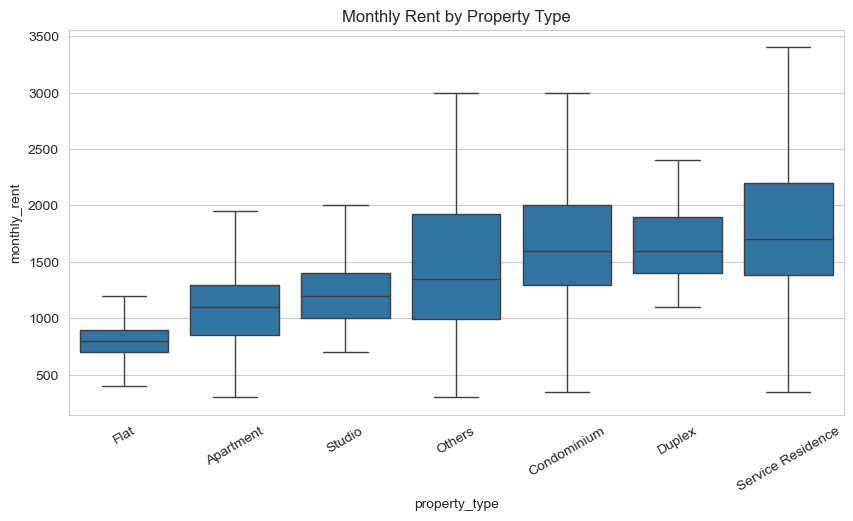

In [16]:
plt.figure(figsize=(10, 5))
order = df.groupby("property_type")["monthly_rent"].median().sort_values().index
sns.boxplot(data=df, x="property_type", y="monthly_rent", order=order, showfliers=False)
plt.title("Monthly Rent by Property Type")
plt.xticks(rotation=30)
plt.show()

**Insight:** Flats are the cheapest (median RM 800). Condominiums (RM 1,600) and Service Residences (RM 1,700) are the most expensive.

### 4.4 Rent by furnishing

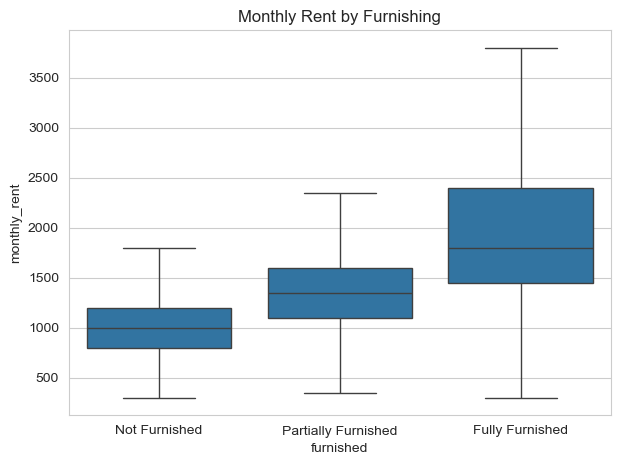

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="furnished", y="monthly_rent", showfliers=False,
            order=["Not Furnished", "Partially Furnished", "Fully Furnished"])
plt.title("Monthly Rent by Furnishing")
plt.show()


**Insight:** fully furnished units (median RM 1,800) cost almost double not furnished units (RM 1,000).

### 4.5 Kuala Lumpur vs Selangor

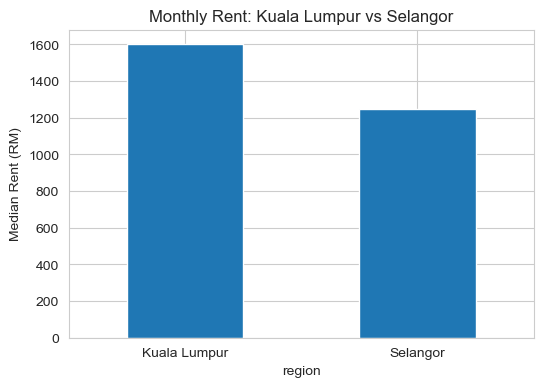

In [18]:
df.groupby("region")["monthly_rent"].median().plot(kind="bar", figsize=(6, 4))
plt.title("Monthly Rent: Kuala Lumpur vs Selangor")
plt.ylabel("Median Rent (RM)")
plt.xticks(rotation=0)
plt.show()

**Insight:** Kuala Lumpur (median RM 1,600) is more expensive than Selangor (RM 1,250).

### 4.6 Most expensive and cheapest areas
We only use areas with at least 30 listings, so the result is reliable.

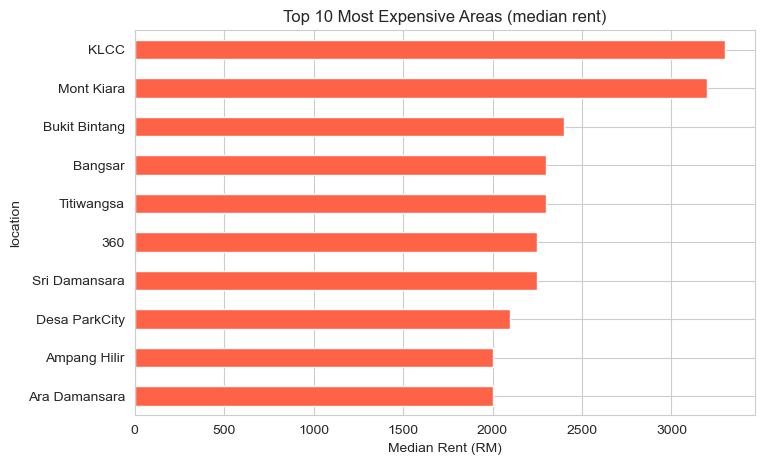

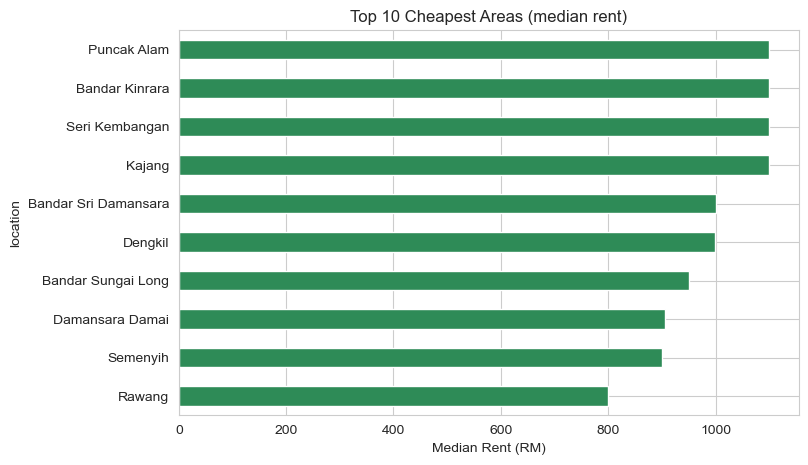

In [19]:
# Step 1: keep only areas with at least 30 listings
area_counts = df["location"].value_counts()
big_areas = area_counts[area_counts >= 30].index
df_big = df[df["location"].isin(big_areas)]

# Step 2: median rent for each area, sorted from cheapest to most expensive
area_rent = df_big.groupby("location")["monthly_rent"].median().sort_values()

# Chart 1: most expensive areas
area_rent.tail(10).plot(kind="barh", color="tomato", figsize=(8, 5))
plt.title("Top 10 Most Expensive Areas (median rent)")
plt.xlabel("Median Rent (RM)")
plt.show()

# Chart 2: cheapest areas
area_rent.head(10).plot(kind="barh", color="seagreen", figsize=(8, 5))
plt.title("Top 10 Cheapest Areas (median rent)")
plt.xlabel("Median Rent (RM)")
plt.show()

**Insight:** KLCC (RM 3,300) and Mont Kiara (RM 3,200) are the most expensive. Rawang (RM 800) and Semenyih (RM 900) are the cheapest. Location is a very strong factor.

### 4.7 Size vs rent

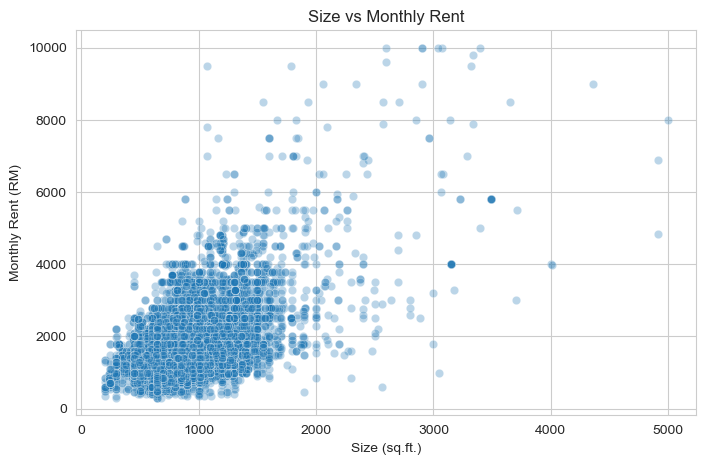

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="size", y="monthly_rent", alpha=0.3)
plt.title("Size vs Monthly Rent")
plt.xlabel("Size (sq.ft.)")
plt.ylabel("Monthly Rent (RM)")
plt.show()

**Insight:** bigger units usually cost more, but the points are spread out, because location also changes the price a lot.

### 4.8 Correlation heatmap

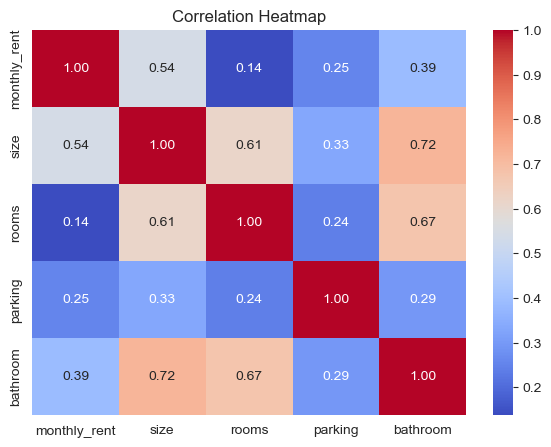

In [21]:
plt.figure(figsize=(7, 5))
num_cols = ["monthly_rent", "size", "rooms", "parking", "bathroom"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Insight:** size has the strongest link with rent (0.54), then bathroom (0.39). Rooms is weak (0.14), because many cheap flats also have 3 rooms.

### EDA summary
1. Location matters a lot: KLCC and Mont Kiara cost about 4 times more than Rawang.
2. Fully furnished units cost much more.
3. Condominiums and Service Residences are more expensive than Flats.
4. Bigger units cost more, but size alone doesn't explain everything.
5. Kuala Lumpur is more expensive than Selangor.

## Step 5: Prepare the data

### 5.1 Features (X) and target (y)
- **X** = the information we give the model
- **y** = what we want to predict (monthly rent)

In [22]:
X = df.drop(columns=["monthly_rent"])
y = df["monthly_rent"]

### 5.2 Encode the text columns
Models only understand numbers. `get_dummies` turns each text option into a 0/1 column.

In [23]:
X = pd.get_dummies(X, drop_first=True)
print("Number of columns after encoding:", X.shape[1])
X.head()

Number of columns after encoding: 137


,rooms,parking,bathroom,size,location_369,location_389,location_517,location_639,location_Alam Impian,location_Ampang,location_Ampang Hilir,location_Ara Damansara,location_Balakong,location_Bandar Botanic,location_Bandar Bukit Raja,location_Bandar Bukit Tinggi,location_Bandar Damai Perdana,location_Bandar Kinrara,location_Bandar Mahkota Cheras,location_Bandar Menjalara,location_Bandar Saujana Putra,location_Bandar Sri Damansara,location_Bandar Sungai Long,location_Bandar Sunway,location_Bandar Tasik Selatan,location_Bandar Utama,location_Bangi,location_Bangsar,location_Bangsar South,location_Banting,location_Batu Caves,location_Beranang,location_Brickfields,location_Bukit Beruntung,location_Bukit Bintang,location_Bukit Jalil,location_Bukit Jelutong,location_Bukit Subang,location_Bukit Tunku,location_Cheras,location_City Centre,location_Cyberjaya,location_Damansara,location_Damansara Damai,location_Damansara Heights,location_Damansara Jaya,location_Damansara Perdana,location_Dengkil,location_Desa Pandan,location_Desa ParkCity,location_Desa Petaling,location_Glenmarie,location_Gombak,location_Hulu Langat,location_I-City,location_Jalan Ipoh,location_Jalan Kuching,location_Jalan Sultan Ismail,location_Jenjarom,location_Jinjang,location_KL City,location_KL Eco City,location_KL Sentral,location_KLCC,location_Kajang,location_Kapar,location_Kelana Jaya,location_Kepong,location_Keramat,location_Klang,location_Kota Damansara,location_Kota Kemuning,location_Kuala Langat,location_Kuala Selangor,location_Kuchai Lama,location_Mid Valley City,location_Mont Kiara,location_Mutiara Damansara,location_OUG,location_Old Klang Road,location_Others,location_Pandan Indah,location_Pandan Jaya,location_Pandan Perdana,location_Pantai,location_Petaling Jaya,location_Port Klang,location_Puchong,location_Puchong South,location_Pudu,location_Pulau Indah (Pulau Lumut),location_Puncak Alam,location_Puncak Jalil,location_Putra Heights,location_Rawang,location_Salak Selatan,location_Salak Tinggi,location_Saujana Utama,location_Segambut,location_Selayang,location_Semenyih,location_Sentul,location_Sepang,location_Seputeh,location_Serdang,location_Serendah,location_Seri Kembangan,location_Setapak,location_Setia Alam,location_Setiawangsa,location_Shah Alam,location_Solaris Dutamas,location_Sri Damansara,location_Sri Hartamas,location_Sri Petaling,location_Subang Bestari,location_Subang Jaya,location_Sungai Besi,location_Sungai Buloh,location_Sungai Penchala,location_Taman Desa,location_Taman Melawati,location_Taman Tun Dr Ismail,location_Telok Panglima Garang,location_Titiwangsa,location_USJ,location_Ulu Klang,location_Wangsa Maju,property_type_Condominium,property_type_Duplex,property_type_Flat,property_type_Others,property_type_Service Residence,property_type_Studio,furnished_Not Furnished,furnished_Partially Furnished,region_Selangor
0,5.0,2.0,6.0,1842,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,3.0,1.0,2.0,1170,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

### 5.3 Train/test split (80% / 20%)
The model learns from 80% of the data and is tested on the other 20%, which it has never seen.
`random_state=42` makes the split the same every time.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 14606
Testing rows: 3652


### 5.4 Scale the data
Scaling puts all numbers on a similar range, which helps Linear Regression.
We `fit` the scaler on the training data only, so no information from the test data leaks into training (no data leakage).

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 6: Train the models

- **Linear Regression** – finds the best straight-line relationship between the features and rent. A simple baseline.
- **Random Forest** – builds many decision trees (each asks yes/no questions like "Is size > 1000?") and averages their answers. It can learn complex patterns, like location changing the price a lot.

### 6.1 Linear Regression

In [26]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2  :", r2_score(y_test, lr_pred))

MAE : 310.3491543788421
MSE : 236850.0831421646
RMSE: 486.67245981477583
R2  : 0.6649492280541458


### 6.2 Random Forest
`max_features=0.33` means each question in a tree only looks at a random third of the columns. This makes the trees more different from each other, so more of them learn from the area columns (location), which is very important for rent.

In [27]:
rf = RandomForestRegressor(max_features=0.33, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2  :", r2_score(y_test, rf_pred))

MAE : 216.79708232119452
MSE : 157841.06313742377
RMSE: 397.29216344829126
R2  : 0.7767162698557927


## Step 7: Evaluation

### 7.1 Compare the models

In [28]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, rf_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, lr_pred)), np.sqrt(mean_squared_error(y_test, rf_pred))],
    "R2": [r2_score(y_test, lr_pred), r2_score(y_test, rf_pred)],
})
results

,Model,MAE,RMSE,R2
0,Linear Regression,310.349154,486.672460,0.664949
1,Random Forest,216.797082,397.292163,0.776716


**What the metrics mean**
- **MAE** – the average mistake, in RM
- **MSE** – the average of squared mistakes (big mistakes count more)
- **RMSE** – the square root of MSE, back in RM
- **R²** – how much of the rent the model explains (1 = perfect, 0 = useless)

**Interpretation**
- **Random Forest is the best model.** On average, its prediction is about **RM 217** away from the real rent, and it explains about **78%** of the rent (R² = 0.78).
- Linear Regression is worse (MAE RM 310, R² = 0.66), because the link between the features and rent is not a straight line.
- RMSE (RM 397) is bigger than MAE, so there are still some big mistakes, mostly on expensive luxury units.

### 7.2 Most important features

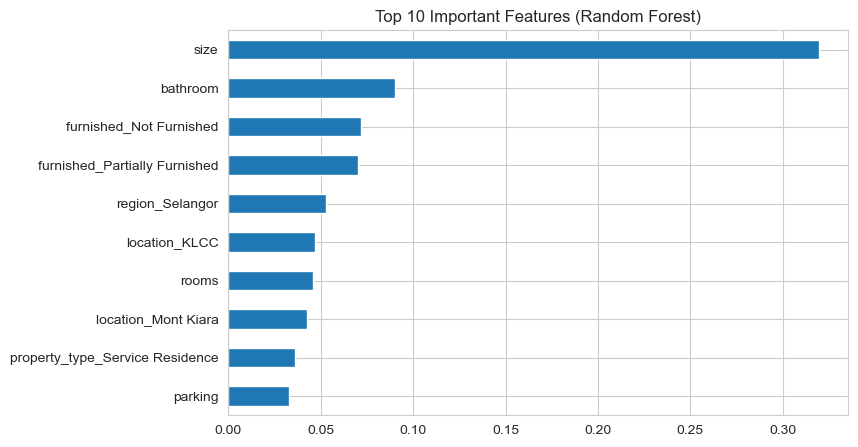

In [29]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

**Insight:** size is by far the most important feature, then bathrooms, furnishing, region (KL or Selangor) and expensive areas like KLCC and Mont Kiara. This matches the EDA.

## Step 8: Try a prediction
We give the model one new property, encode it the same way, scale it, and predict.

In [30]:
new_house = pd.DataFrame([{
    "location": "Cheras",
    "property_type": "Condominium",
    "rooms": 3,
    "parking": 1,
    "bathroom": 2,
    "size": 1000,
    "furnished": "Fully Furnished",
    "region": "Kuala Lumpur",
}])

new_house = pd.get_dummies(new_house)
new_house = new_house.reindex(columns=X.columns, fill_value=0)   # same columns as training
new_house = scaler.transform(new_house)

print("Predicted rent: RM", round(rf.predict(new_house)[0]))

Predicted rent: RM 1584


## Step 9: Classification with ROC and AUC
ROC and AUC only work when we predict a **group**, not a number. So we ask a new question:

**Is the property Expensive (1) or Affordable (0)?**
Expensive = rent above the median rent of the training data.

In [31]:
threshold = y_train.median()
print("Expensive = rent above RM", threshold)

y_train_class = (y_train > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

Expensive = rent above RM 1450.0


### 9.1 Train two classification models
- **Logistic Regression** – gives the probability that a property is Expensive
- **Random Forest Classifier** – many decision trees vote Expensive or Affordable

In [32]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_class)

rf_class = RandomForestClassifier(random_state=42)
rf_class.fit(X_train_scaled, y_train_class);

### 9.2 Accuracy, precision, recall and F1
- **Accuracy** – how many predictions are correct
- **Precision** – when the model says Expensive, how often it is right
- **Recall** – how many of the truly Expensive units it found
- **F1** – a balance of precision and recall

In [33]:
print("Logistic Regression")
print(classification_report(y_test_class, log_model.predict(X_test_scaled)))

print("Random Forest")
print(classification_report(y_test_class, rf_class.predict(X_test_scaled)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1816
           1       0.85      0.84      0.85      1836

    accuracy                           0.85      3652
   macro avg       0.85      0.85      0.85      3652
weighted avg       0.85      0.85      0.85      3652

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1816
           1       0.87      0.88      0.87      1836

    accuracy                           0.87      3652
   macro avg       0.87      0.87      0.87      3652
weighted avg       0.87      0.87      0.87      3652



### 9.3 Confusion matrix (Random Forest)

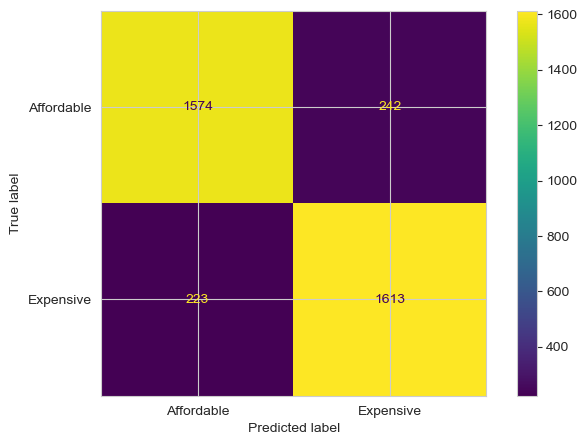

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test_class, rf_class.predict(X_test_scaled),
                                        display_labels=["Affordable", "Expensive"])
plt.show()

The diagonal boxes (top-left and bottom-right) are correct predictions. The other two boxes are mistakes.

### 9.4 ROC curve and AUC
- The ROC curve shows how well the model separates Expensive and Affordable.
- The closer the curve is to the top-left corner, the better.
- **AUC**: 1.0 = perfect, 0.5 = random guessing.

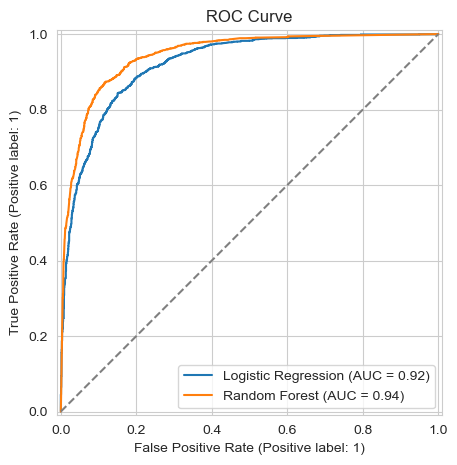

In [35]:
ax = plt.gca()
RocCurveDisplay.from_estimator(log_model, X_test_scaled, y_test_class, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(rf_class, X_test_scaled, y_test_class, name="Random Forest", ax=ax)
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.title("ROC Curve")
plt.show()

**Interpretation**
- Both curves are far above the grey line (random guessing), so both models separate Expensive and Affordable units well.
- **Random Forest has the higher AUC (0.95)**, compared with 0.92 for Logistic Regression.
- Random Forest accuracy is 87%: about 9 out of 10 units are put in the correct group.

## Step 10: Export the model for the React web app (SewaCheck)
A web browser cannot run Python. So we save a Random Forest as `model.json`, a text file that JavaScript can read.

The full Random Forest is too big for a website, so we train a **small one**:
- `n_estimators=30` → 30 trees instead of 100
- `min_samples_leaf=3` → each final answer is based on at least 3 listings (this keeps the trees smaller)
- `max_features=0.33` → the same setting as our main Random Forest

Trees don't need scaled data, so we use `X_train`.

In [36]:
web_rf = RandomForestRegressor(n_estimators=30, min_samples_leaf=3, max_features=0.33, random_state=42)
web_rf.fit(X_train, y_train)

web_mae = mean_absolute_error(y_test, web_rf.predict(X_test))
print("Small model - average error (MAE): RM", round(web_mae))

Small model - average error (MAE): RM 240


Each tree is saved as 5 lists:
- `feature` – which column the tree checks (e.g. size)
- `threshold` – the number it compares with (e.g. 875.5)
- `left` / `right` – where to go next (-1 means the end)
- `value` – the predicted rent at the end

We also save:
- for each area: its region (so the website fills it in by itself), its median rent and its number of listings
- market numbers (median rent by region, property type and furnishing) for the dashboard page

In [37]:
# 1. Save every tree as simple lists
trees = []
for tree in web_rf.estimators_:
    trees.append({
        "feature": tree.tree_.feature.tolist(),
        "threshold": tree.tree_.threshold.round(3).tolist(),
        "left": tree.tree_.children_left.tolist(),
        "right": tree.tree_.children_right.tolist(),
        "value": tree.tree_.value[:, 0, 0].round(1).tolist(),
    })

# 2. Information about each area: region, median rent and number of listings
areas = {}
for loc in sorted(df["location"].unique()):
    area_df = df[df["location"] == loc]
    areas[loc] = {
        "region": area_df["region"].mode()[0],
        "median": float(area_df["monthly_rent"].median()),
        "count": len(area_df),
    }

# 3. Market numbers for the "Market overview" page
market = {
    "total_listings": len(df),
    "median_rent": float(df["monthly_rent"].median()),
    "by_region": df.groupby("region")["monthly_rent"].median().to_dict(),
    "by_type": df.groupby("property_type")["monthly_rent"].median().to_dict(),
    "by_furnished": df.groupby("furnished")["monthly_rent"].median().to_dict(),
}

# 4. Put everything together and save
web_model = {
    "columns": list(X.columns),
    "areas": areas,
    "property_types": sorted(df["property_type"].unique().tolist()),
    "furnished": sorted(df["furnished"].unique().tolist()),
    "mae": round(web_mae),
    "market": market,
    "trees": trees,
}

with open("model.json", "w") as f:
    json.dump(web_model, f)

print("Saved model.json - copy it into the React folder: frontend/public/")

Saved model.json - copy it into the React folder: frontend/public/


## Step 11: Conclusion

**Findings**
- Rent is driven mostly by size, furnishing, location and property type.
- Random Forest was the best model: MAE about RM 217 and R² 0.78.
- For Expensive vs Affordable, Random Forest reached 87% accuracy and AUC 0.95.

